# Task A: EDA & Degradation Understanding
In this notebook, we perform exploratory data analysis on the NASA CMAPSS FD001 dataset. Our goal is to understand the fundamental degradation behavior, identify operational regimes, and prune noisy or useless sensors to prepare for feature engineering.

In [1]:
 # import library 


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Suppress annoying warning messages to keep the notebook output clean
warnings.filterwarnings('ignore')

# Set seaborn aesthetic parameters to use a clean, professional white grid background
plt.style.use('seaborn-v0_8-whitegrid')
# Scale up the font size slightly for better readability in presentations
sns.set_context("notebook", font_scale=1.1)

/tmp/ipykernel_19082/1724297767.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [6]:

# ==============================================================================
# 1. LOAD DATA
# ==============================================================================

# Define the exact column names: unit ID, cycle count, 3 operational settings, and 21 sensors
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

# Read the training dataset from the text file, separated by whitespace, without a header row, applying our columns
train = pd.read_csv('/home/user/risk-aware-predictive-maintenance/data/archive/CMaps/train_FD001.txt', sep=r'\s+', header=None, names=cols)
# Read the testing dataset using the exact same format
test  = pd.read_csv('/home/user/risk-aware-predictive-maintenance/data/archive/CMaps/test_FD001.txt',  sep=r'\s+', header=None, names=cols)

# Print the total number of rows and columns in the training set
print(f"Train Shape: {train.shape}")
# Print the count of unique engine IDs in the training set
print(f"Total Train Engines: {train['unit'].nunique()}\n")


Train Shape: (20631, 26)
Total Train Engines: 100



=== 2. MACRO FLEET ANALYSIS ===


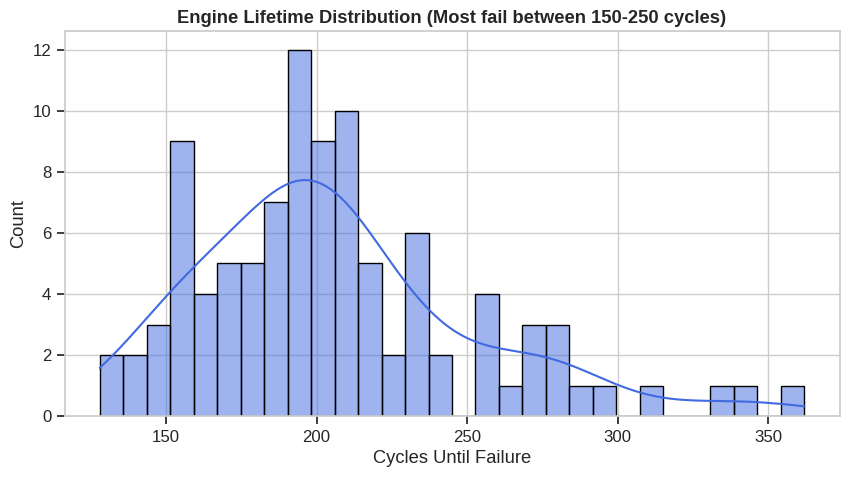

Operational Settings Variance:
           op1       op2    op3
mean -0.000009  0.000002  100.0
std   0.002187  0.000293    0.0
min  -0.008700 -0.000600  100.0
max   0.008700  0.000600  100.0
-> Insight: op1/op2 have near-zero std, op3 is constant. FD001 is a single operating regime.



In [ ]:
# ==============================================================================
# 2. MACRO FLEET ANALYSIS (LIFETIMES & REGIMES)
# ==============================================================================
print("=== 2. MACRO FLEET ANALYSIS ===")

# Group the training data by engine unit and find the maximum cycle (lifetime) for each
lifetimes = train.groupby('unit')['cycle'].max()

# Create a new matplotlib figure with a specific size (10 inches wide, 5 inches tall)
plt.figure(figsize=(10, 5))
# Plot a histogram of engine lifetimes, using 30 bins, and overlay a KDE (Kernel Density Estimate) curve
sns.histplot(lifetimes, bins=30, kde=True, color='royalblue')

plt.title('Engine Lifetime Distribution (Most fail between 150-250 cycles)', fontweight='bold')

plt.xlabel('Cycles Until Failure')

plt.show()

# Calculate summary statistics (mean, std, min, max) for the three operational settings
op_stats = train[['op1', 'op2', 'op3']].describe().loc[['mean', 'std', 'min', 'max']]

print("Operational Settings Variance:")
print(op_stats)
# Print an insight explaining that the lack of variance means FD001 has only one flight regime
print("-> Insight: op1/op2 have near-zero std, op3 is constant. FD001 is a single operating regime.\n")

### Insight 1: Operational Settings & Flight Regimes
**Do the operational settings create different regimes?** No. The FD001 dataset represents a **single operating regime**. Analysis of the operational settings (`op1`, `op2`, `op3`) reveals almost zero variance. 
* `op3` is entirely constant at 100.0. 
* `op1` and `op2` have near-zero standard deviations (0.002 and 0.0002, respectively). 
Because the environmental and throttle conditions are completely static, any variance we observe in the sensors is strictly due to mechanical degradation, not changes in flight conditions.

In [8]:
# ==============================================================================
# 3. SENSOR PRUNING (VARIANCE ANALYSIS)
# ==============================================================================
print("=== 3. SENSOR PRUNING ===")

# Create a list containing only the names of the 21 sensor columns
sensor_cols = [f's{i}' for i in range(1, 22)]
# Calculate the standard deviation for every sensor column
sensor_stds = train[sensor_cols].std()

# Filter for sensors where the standard deviation is practically zero (less than 0.0001)
constant_sensors = sensor_stds[sensor_stds < 1e-4].index.tolist()
# Create a new list keeping only the sensors that are NOT in the constant_sensors list
active_sensors = [s for s in sensor_cols if s not in constant_sensors]

# Print the list of useless sensors that will be dropped
print(f"Dropped Constant/Dead Sensors: {constant_sensors}")
# Print the list of sensors that actually contain varying data
print(f"Retained Active Sensors: {active_sensors}\n")

=== 3. SENSOR PRUNING ===
Dropped Constant/Dead Sensors: ['s1', 's5', 's10', 's16', 's18', 's19']
Retained Active Sensors: ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']



### Insight 2: Sensor Selection & Redundancy
To build a robust model, we must separate the signal from the noise.
* **Constant Sensors:** 6 sensors were completely flat (standard deviation < 0.0001) and provided no predictive value. These were safely dropped: `s1, s5, s10, s16, s18, s19`.
* **Strong Degradation Signals (Monotonicity):** By calculating the Spearman Rank correlation against the time cycle, we found the sensors that best track the continuous wear and tear of the engine. The strongest degradation predictors are `s11, s12, s4, s7, and s15`.
* **Redundancy:** The Heatmap shows massive inter-sensor redundancy. Many of the high-temperature and high-pressure sensors degrade in lockstep, suggesting that dimensionality reduction (PCA) or building a composite Health Index will be highly effective.

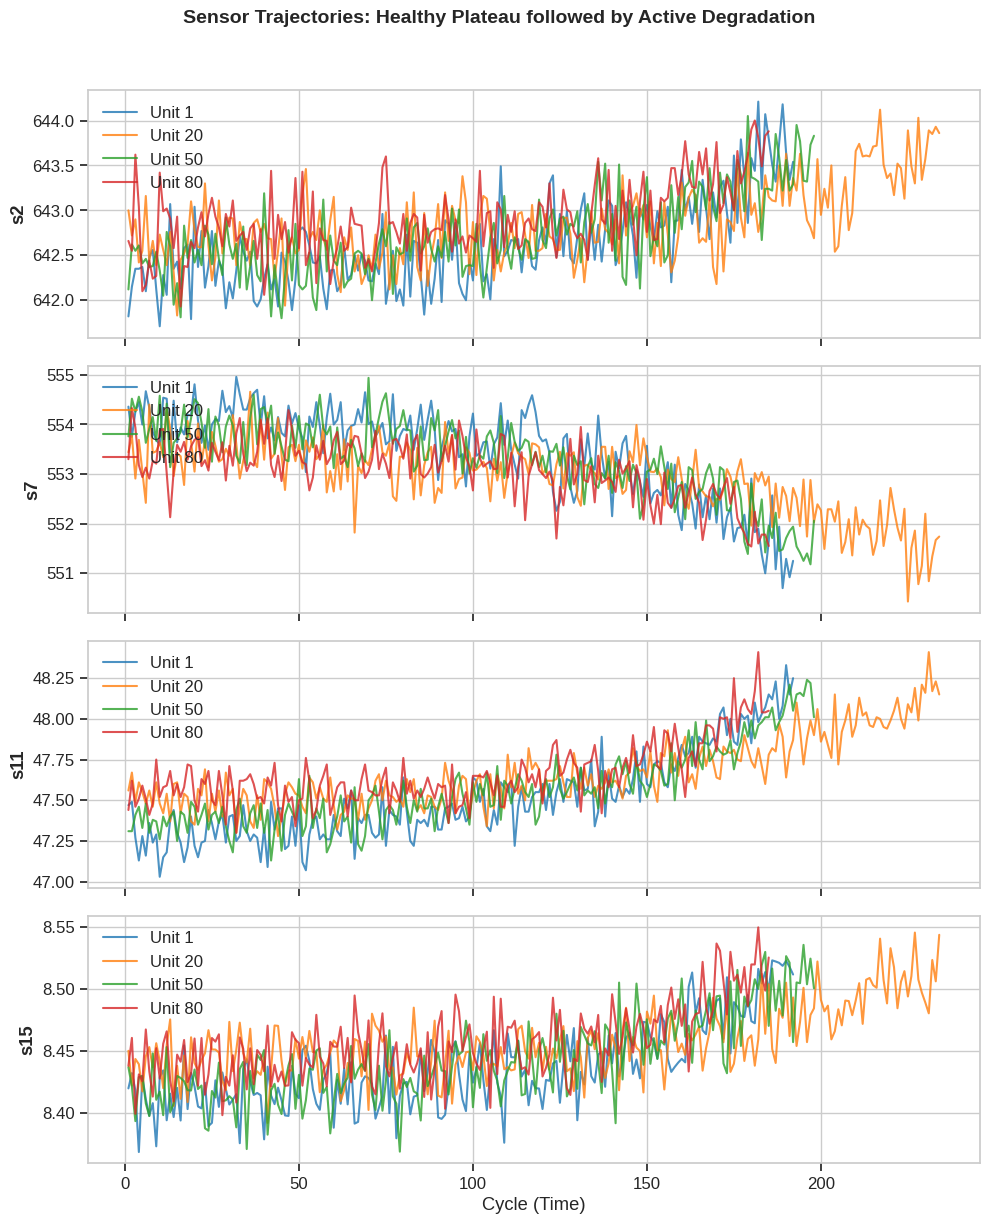

In [9]:
# ==============================================================================
# 4. DEGRADATION VISUALIZATION (TRAJECTORIES)
# ==============================================================================
# Define a list of 4 specific engines to sample for visualization
example_units = [1, 20, 50, 80]
# Select 4 key sensors that are known to show strong degradation patterns
key_sensors = ['s2', 's7', 's11', 's15']

# Create a grid of subplots: 4 rows (one for each sensor), 1 column, sharing the x-axis
fig, axes = plt.subplots(len(key_sensors), 1, figsize=(10, 12), sharex=True)

# Loop through each chosen key sensor along with its index
for i, sensor in enumerate(key_sensors):
    # Loop through each of the 4 example engines
    for unit in example_units:
        # Filter the dataset to isolate data for just this specific engine
        data = train[train['unit'] == unit]
        # Plot the cycle count on x, and the sensor reading on y, labeling the line with the unit ID
        axes[i].plot(data['cycle'], data[sensor], label=f'Unit {unit}', alpha=0.8)

    # Set the y-axis label to the current sensor's name
    axes[i].set_ylabel(sensor, fontweight='bold')
    # Add a legend to the subplot to identify the lines
    axes[i].legend(loc='upper left')

# Add a main title to the entire figure
plt.suptitle('Sensor Trajectories: Healthy Plateau followed by Active Degradation', fontsize=14, fontweight='bold', y=1.02)
# Label the shared x-axis at the very bottom
plt.xlabel('Cycle (Time)')
# Automatically adjust the padding between subplots so labels don't overlap
plt.tight_layout()
# Display the trajectory plot
plt.show()

=== 5. SIGNAL STRENGTH & REDUNDANCY ===
Top 5 Monotonic Sensors (Best Predictors):
     Spearman_Rank
s11       0.809681
s12       0.784045
s4        0.774117
s7        0.751666
s15       0.710880




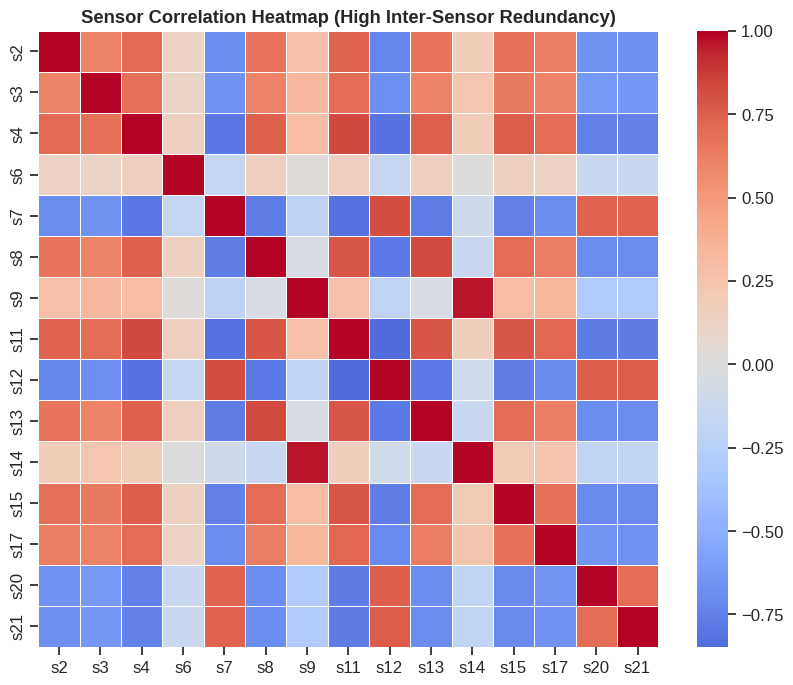

In [ ]:
# ==============================================================================
# 5. SIGNAL STRENGTH & REDUNDANCY (MONOTONICITY & HEATMAP)
# ==============================================================================
print("=== 5. SIGNAL STRENGTH & REDUNDANCY ===")

# Create an empty dictionary to store the Spearman correlation values for each sensor
monotonicity = {}

# Loop through every active sensor
for sensor in active_sensors:
    # Create an empty list to store the correlation scores for individual engines
    corrs = []
    # Loop through every unique engine ID in the training set
    for unit in train['unit'].unique():
        # Isolate the data for the current engine
        data = train[train['unit'] == unit]
        # Calculate the Spearman rank correlation (rho) between time (cycle) and the sensor reading
        rho, _ = spearmanr(data['cycle'], data[sensor])
        # Append the absolute value of the correlation to our list (we care about magnitude, not direction)
        corrs.append(abs(rho))
    # Calculate the average correlation across all engines for this specific sensor and save it to the dictionary
    monotonicity[sensor] = np.mean(corrs)

# Convert the dictionary into a pandas DataFrame, sort it from highest correlation to lowest
mono_df = pd.DataFrame.from_dict(monotonicity, orient='index', columns=['Spearman_Rank']).sort_values(by='Spearman_Rank', ascending=False)
# Print the top 5 most monotonic (predictive) sensors
print("Top 5 Monotonic Sensors (Best Predictors):")
print(mono_df.head(5))
print("\n")

# Calculate the Pearson correlation matrix between all active sensors to check for redundancy
corr_matrix = train[active_sensors].corr()

# Create a figure for the heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)

plt.title('Sensor Correlation Heatmap (High Inter-Sensor Redundancy)', fontweight='bold')

plt.show()

=== 6. LIFE-STAGE ANALYSIS ===


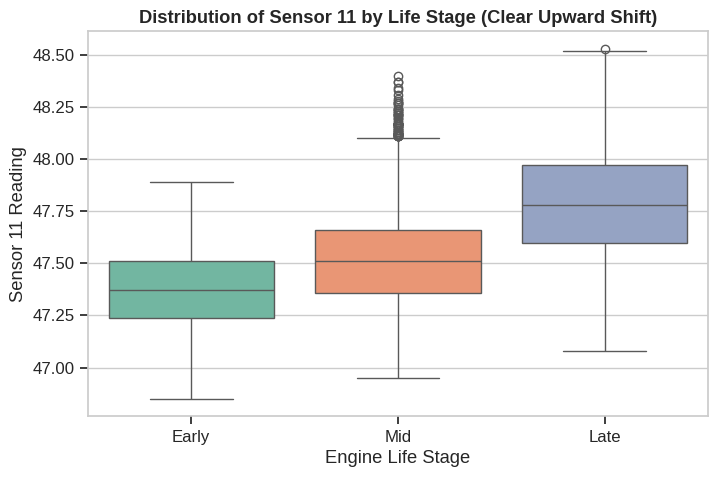

In [12]:
# ==============================================================================
# 6. LIFE-STAGE ANALYSIS
# ==============================================================================
print("=== 6. LIFE-STAGE ANALYSIS ===")

# Create a new column 'life_stage' by binning the cycle count into Early, Mid, and Late categories
train['life_stage'] = pd.cut(train['cycle'], bins=[0, 75, 150, 400], labels=['Early', 'Mid', 'Late'])

# Create a figure for the boxplot
plt.figure(figsize=(8, 5))
# Plot a boxplot showing the distribution of Sensor 11 across the three life stages
sns.boxplot(data=train, x='life_stage', y='s11', palette='Set2')

plt.title('Distribution of Sensor 11 by Life Stage (Clear Upward Shift)', fontweight='bold')

plt.xlabel('Engine Life Stage')

plt.ylabel('Sensor 11 Reading')

plt.show()


In [13]:
# ==============================================================================
# 7. TRAIN VS TEST DISTRIBUTION CHECK
# ==============================================================================
print("=== 7. TRAIN VS TEST DISTRIBUTION CHECK ===")

# Create an empty DataFrame to store the comparison metrics
compare = pd.DataFrame()

# Loop through the top 4 most monotonic sensors
for col in mono_df.index[:4]:
    # Calculate the mean and std for both train and test sets, and add them as a column
    compare[col] = [train[col].mean(), test[col].mean(), train[col].std(), test[col].std()]

# Rename the index rows to identify the metrics
compare.index = ['Train_Mean', 'Test_Mean', 'Train_Std', 'Test_Std']
# Print the comparison DataFrame, rounded to 3 decimal places
print("Comparing Top 4 Sensors (Train vs Test):")
print(compare.round(3))
# Print an insight confirming that the data hasn't shifted between sets
print("-> Insight: Means and Stds match closely. No covariate shift detected.\n")


=== 7. TRAIN VS TEST DISTRIBUTION CHECK ===
Comparing Top 4 Sensors (Train vs Test):
               s11      s12        s4       s7
Train_Mean  47.541  521.413  1408.934  553.368
Test_Mean   47.416  521.748  1404.735  553.758
Train_Std    0.267    0.738     9.001    0.885
Test_Std     0.196    0.560     6.688    0.681
-> Insight: Means and Stds match closely. No covariate shift detected.



===  PCA DEGRADATION PATH VISUALIZATION ===
Information captured by 2D PCA: 72.80%
-> Insight: We can compress the entire engine state into 2 dimensions while keeping most of the data.



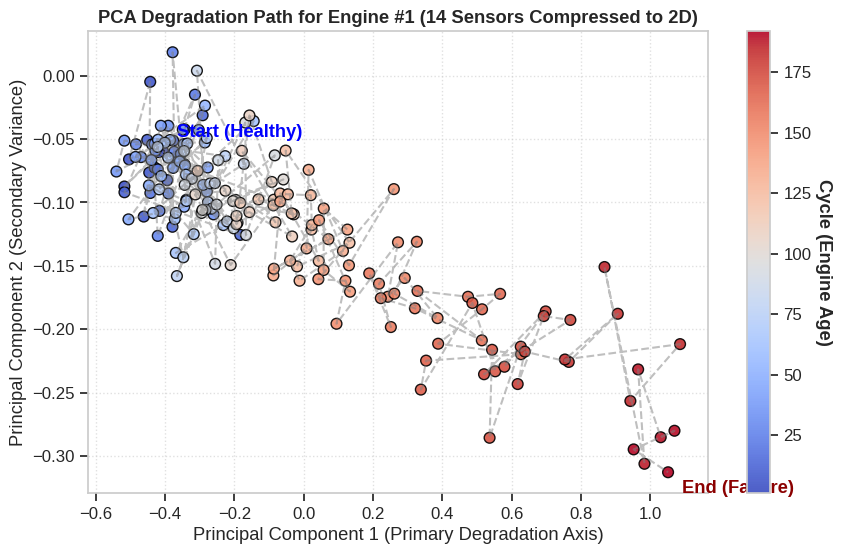

In [ ]:
# ==============================================================================
#  ADVANCED EDA: PCA DEGRADATION PATH (THE "EXPERT" FLEX)
# ==============================================================================
print("===  PCA DEGRADATION PATH VISUALIZATION ===")

# Create a fresh scaler to normalize our active sensors
pca_scaler = MinMaxScaler()
# Normalize the active sensors so sensors with large numbers don't dominate the PCA
scaled_sensors = pca_scaler.fit_transform(train[active_sensors])

# Initialize PCA to reduce our 14+ sensors down to just 2 Principal Components (2D map)
pca = PCA(n_components=2)
# Fit the PCA and transform the 14D data into 2D data
pca_features = pca.fit_transform(scaled_sensors)

# Add these two new "super features" back into our training dataframe for plotting
train['PC1'] = pca_features[:, 0]
train['PC2'] = pca_features[:, 1]

# Print how much of the original variance (information) is captured by just these 2 dimensions
explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"Information captured by 2D PCA: {explained_variance:.2f}%")
print("-> Insight: We can compress the entire engine state into 2 dimensions while keeping most of the data.\n")

# Create a beautiful scatter plot to visualize the degradation path
plt.figure(figsize=(10, 6))

# Let's plot the trajectory of Engine #1 on this new 2D map
engine_1_pca = train[train['unit'] == 1]

# Create a scatter plot of PC1 vs PC2, coloring the dots by the 'cycle' (time)
# As time goes on (cycle increases), the color changes from blue (cool/new) to red (hot/failing)
scatter = plt.scatter(engine_1_pca['PC1'], engine_1_pca['PC2'],
                      c=engine_1_pca['cycle'], cmap='coolwarm',
                      edgecolor='k', s=60, alpha=0.9)

# Add a colorbar to explain that Blue = Early Life, Red = End of Life
cbar = plt.colorbar(scatter)
cbar.set_label('Cycle (Engine Age)', rotation=270, labelpad=15, fontweight='bold')

# Connect the dots with a faint line to show the "path" the engine takes
plt.plot(engine_1_pca['PC1'], engine_1_pca['PC2'], color='gray', linestyle='--', alpha=0.5)

# Add an annotation for the starting point (Cycle 1)
plt.annotate('Start (Healthy)',
             xy=(engine_1_pca['PC1'].iloc[0], engine_1_pca['PC2'].iloc[0]),
             xytext=(10, 10), textcoords='offset points', fontweight='bold', color='blue')

# Add an annotation for the exact moment of failure (Last Cycle)
plt.annotate('End (Failure)',
             xy=(engine_1_pca['PC1'].iloc[-1], engine_1_pca['PC2'].iloc[-1]),
             xytext=(10, -15), textcoords='offset points', fontweight='bold', color='darkred')


plt.title('PCA Degradation Path for Engine #1 (14 Sensors Compressed to 2D)', fontweight='bold')
plt.xlabel('Principal Component 1 (Primary Degradation Axis)')
plt.ylabel('Principal Component 2 (Secondary Variance)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

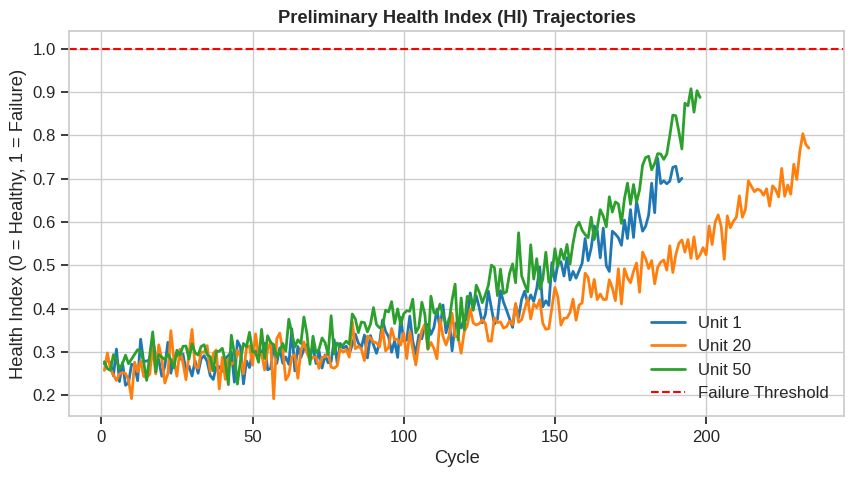

In [ ]:
# ==============================================================================
# 8. PRELIMINARY HEALTH INDEX (HI) TRAJECTORY
# ==============================================================================
# Create a copy of the training data to safely manipulate
norm_train = train.copy()
# Define the subset of active sensors we will use to build the index
trending_sensors = active_sensors

# Loop through each active sensor
for col in trending_sensors:
    # If the sensor trends downwards (negative correlation with cycle), invert it so all sensors trend upwards
    if train[col].corr(train['cycle']) < 0:
        norm_train[col] = 1.0 - norm_train[col]

    # Apply a Min-Max normalization per engine so every sensor scales from 0 to 1
    norm_train[col] = norm_train.groupby('unit')[col].transform(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))

# Calculate the Health Index (HI) by taking the mean of all normalized, aligned sensors
norm_train['HI'] = norm_train[trending_sensors].mean(axis=1)

# Create a figure for the HI plot
plt.figure(figsize=(10, 5))
# Loop through 3 sample engines
for unit in [1, 20, 50]:
    # Isolate the data for the sample engine
    data = norm_train[norm_train['unit'] == unit]
    # Plot the cycle count vs the engineered Health Index
    plt.plot(data['cycle'], data['HI'], label=f'Unit {unit}', linewidth=2)

# Draw a horizontal red dashed line at y=1.0 to represent the failure threshold
plt.axhline(y=1.0, color='red', linestyle='--', label='Failure Threshold')

plt.title('Preliminary Health Index (HI) Trajectories', fontweight='bold')

plt.xlabel('Cycle')

plt.ylabel('Health Index (0 = Healthy, 1 = Failure)')

plt.legend()

plt.show()

### Insight 3: Sensor Trajectories (Healthy → Failure)
Looking at the raw sensor trajectories and the PCA Degradation Path, a clear thermodynamic pattern emerges across the fleet:
* **The Healthy Plateau:** For the first ~50-100 cycles, the sensor readings remain relatively flat and stable. The engine is operating within factory tolerances.
* **Active Degradation:** As the engine ages, the sensors break away from the plateau. Sensors like `s11` shift sharply upward, while sensors like `s7` trend heavily downward, accelerating exponentially as the engine approaches catastrophic failure. 
* **Conclusion:** The 2D PCA plot beautifully captures this unified "degradation path" from the healthy state (blue) to the failure state (red), proving that the underlying physics of the engine failures are mathematically predictable.